In [1]:
import os
import pandas as pd
from pyomo.environ import Constraint, Objective, minimize, value

from tsp_helpers import (
    load_geo_dataframe, load_tsplib_data,
    build_distance_matrix, coords_dict,
    selected_edges_from_model, reconstruct_tour,
    plot_tsp_tour, solve_on_neos
)
from tsp_model_kcycle import (
    create_tsp_model, set_connectivity,
    attach_total_distance, attach_budget, attach_time
)

os.environ["NEOS_EMAIL"] = "antonsivko480@gmail.com"


In [2]:
# ----------------------------
# CONFIG: data source
# ----------------------------
DATA_SOURCE = "excel"   # "excel" або "tsplib"

EXCEL_PATH = "data-model/Data Model.xlsx"
TSPLIB_PATH = "TSPLib-data/eil76.tsp"

# ----------------------------
# CONFIG: TSP / k-cycle
# ----------------------------
s_value = 1
k_value = 5

# ----------------------------
# CONFIG: travel/time/budget parameters
# ----------------------------
group_size = 2
speed_kmph = 50.0
budget_max = 10000
time_max   = 15 * 60.0

COST_SCENARIO = "max"   # "min" | "avg" | "max"
CONNECTIVITY = {"hybrid": "hybrid"} # "flow" | "mtz" | "hybrid"

SOLVER = "cplex"        # NEOS solver name


In [3]:
def add_check_ranges(df):
    """Додає check_min/check_max за логікою min–max (на 1 людину)."""
    df = df.copy()

    for col in ["priceLevel", "avgTastingPricePerPerson", "avgMealPricePerPerson", "avgBottlePrice"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    def compute_row(row):
        price = row.get("priceLevel", None)
        t = row.get("avgTastingPricePerPerson", None)
        m = row.get("avgMealPricePerPerson", None)
        b = row.get("avgBottlePrice", None)

        vals = []
        for v in [price, t, m, b]:
            if v is not None and pd.notna(v):
                vals.append(float(v))

        if not vals:
            return pd.Series({"check_min": float("nan"), "check_max": float("nan")})

        light = min(vals)
        full = sum(float(v) for v in [t, m, b] if v is not None and pd.notna(v))

        candidates = []
        if pd.notna(price):
            candidates.append(float(price))
        candidates.append(full)

        heavy = max(candidates) if candidates else light
        return pd.Series({"check_min": min(light, heavy), "check_max": heavy})

    df[["check_min", "check_max"]] = df.apply(compute_row, axis=1)
    return df


In [4]:
if DATA_SOURCE == "excel":
    df = pd.read_excel(EXCEL_PATH)

    # чистимо ключові поля
    for col in ["id", "lat", "lon", "avgStayMinutes"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=["id", "lat", "lon"]).copy()
    df["id"] = df["id"].astype(int)
    df = df.sort_values("id").reset_index(drop=True)

    # 1) координати (geo -> euclid)
    nodes, xcoord_data, ycoord_data = load_geo_dataframe(
        df, id_col="id", lat_col="lat", lon_col="lon", R=6371.0
    )

    # 2) check_min/check_max + cost per person
    df = add_check_ranges(df)

    if COST_SCENARIO == "min":
        df["cost_pp"] = df["check_min"]
    elif COST_SCENARIO == "avg":
        df["cost_pp"] = (df["check_min"] + df["check_max"]) / 2.0
    else:
        df["cost_pp"] = df["check_max"]

    df["cost_pp"] = pd.to_numeric(df["cost_pp"], errors="coerce").fillna(0.0)
    cost_per_person = dict(zip(df["id"], df["cost_pp"]))

    # 3) stay time (minutes)
    if "avgStayMinutes" in df.columns:
        df["avgStayMinutes"] = pd.to_numeric(df["avgStayMinutes"], errors="coerce").fillna(0.0)
        stay_minutes = dict(zip(df["id"], df["avgStayMinutes"]))
    else:
        stay_minutes = {i: 0.0 for i in nodes}

    print("Loaded from Excel:", EXCEL_PATH, "| nodes:", len(nodes))

elif DATA_SOURCE == "tsplib":
    nodes, xcoord_data, ycoord_data = load_tsplib_data(TSPLIB_PATH)
    cost_per_person = {i: 0.0 for i in nodes}
    stay_minutes = {i: 0.0 for i in nodes}
    print("Loaded from TSPLIB:", TSPLIB_PATH, "| nodes:", len(nodes))
else:
    raise ValueError("DATA_SOURCE must be 'excel' or 'tsplib'")

if s_value not in nodes:
    s_value = min(nodes)
    print("Adjusted s_value to:", s_value)

if k_value > len(nodes) - 1:
    k_value = len(nodes) - 1
    print("Adjusted k_value to:", k_value)


Loaded from Excel: data-model/Data Model.xlsx | nodes: 10


In [5]:
d_data = build_distance_matrix(nodes, xcoord_data, ycoord_data, rounding=2)
print("Distance matrix elements:", len(d_data))

model = create_tsp_model(
    nodes=nodes,
    s=s_value,
    k=k_value,
    xcoord_data=xcoord_data,
    ycoord_data=ycoord_data,
    d_data=d_data
)

set_connectivity(model, CONNECTIVITY)

# expressions for constraints / reporting
attach_total_distance(model)
attach_budget(model, cost_per_person, group_size=group_size)
attach_time(model, stay_minutes, speed_kmph=speed_kmph)


Distance matrix elements: 90


In [6]:
# distance objective уже стоїть як model.dk_min
# додаємо обмеження:
model.con_budget = Constraint(expr=model.total_budget <= float(budget_max))
model.con_time   = Constraint(expr=model.total_time   <= float(time_max))



Problem: 
- Lower bound: -.inf
  Upper bound: .inf
  Number of objectives: 1
  Number of constraints: 0
  Number of variables: 199
  Sense: unknown
Solver: 
- Status: ok
  Message: CPLEX 22.1.2\x3a optimal solution; objective 87.35; 591 simplex iterations; absmipgap=1.42109e-14, relmipgap=0
  Termination condition: optimal
  Id: 0
Solution: 
- number of solutions: 0
  number of solutions displayed: 0

Objective = 87.35
Total distance = 87.35
Total budget   = 9740.0
Total time     = 584.82 minutes
Tour: [1, 5, 3, 8, 7, 4, 1]


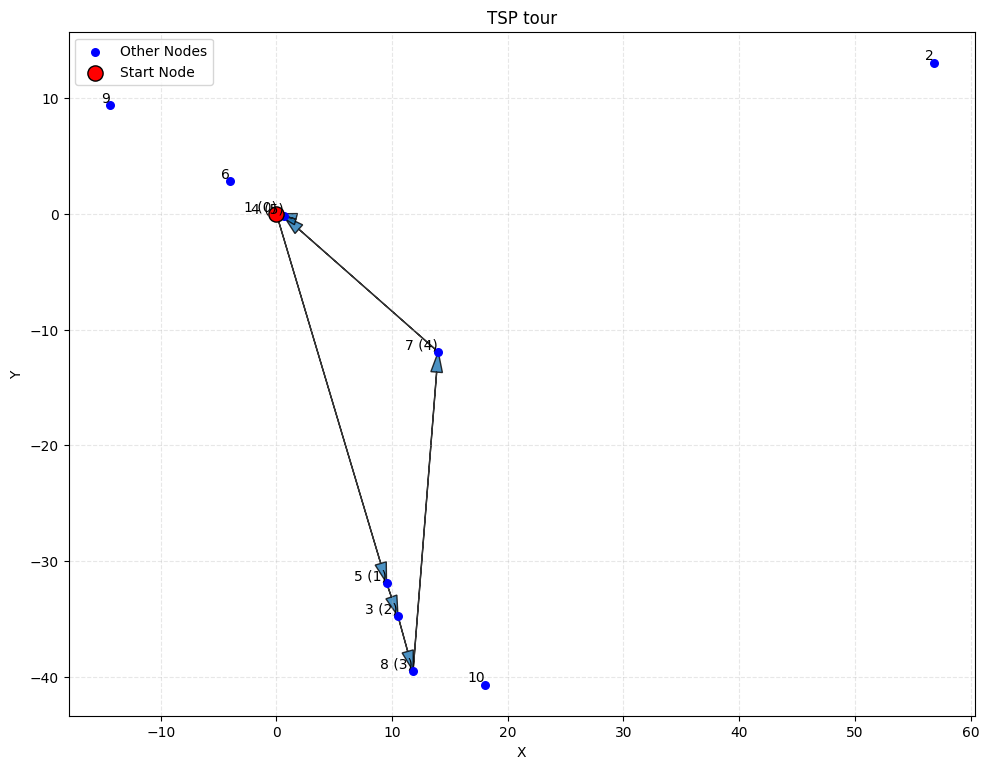

In [7]:
results, ok = solve_on_neos(model, optimizer=SOLVER, neos_email=os.environ["NEOS_EMAIL"], tee=False)
print(results)

if not ok:
    print("NEOS failed:", results.solver.status, results.solver.termination_condition)
else:
    # Вивід ключових метрик:
    if hasattr(model, "obj"):
        print("Objective =", value(model.obj))
    else:
        print("Objective =", value(model.dk_min))

    print("Total distance =", value(model.total_distance))
    print("Total budget   =", value(model.total_budget))
    print("Total time     =", value(model.total_time), "minutes")

    edges = selected_edges_from_model(model, threshold=0.5)
    tour = reconstruct_tour(edges, start=s_value)
    print("Tour:", tour)

    coords = coords_dict(nodes, xcoord_data, ycoord_data)
    plot_tsp_tour(coords, tour, title="TSP tour")
